# **Deliverable 4: MRI Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 25–28** (Weeks 10–11) of the course. You will explore the complete physics foundation underlying Magnetic Resonance Imaging — from spin relaxation and tissue contrast through spatial encoding, pulse sequences, and advanced techniques.

Upon successful completion, you will be able to:
1. **Analyze** T1 and T2 relaxation dynamics and explain how TR and TE determine image contrast.
2. **Design** MRI spatial encoding schemes using gradient fields and describe k-space filling strategies.
3. **Compare** gradient echo, spin echo, fast spin echo, and inversion recovery pulse sequences.
4. **Implement** MRI image reconstruction from k-space data using the Fourier transform.
5. **Evaluate** diffusion-weighted imaging for clinical applications (e.g., acute stroke detection).
6. **Identify and mitigate** common MRI artifacts and explain MRI safety hazards.

---

# Part 1: Relaxation, Contrast, and Timing Parameters

## Key Concepts

**T1 Relaxation (Spin-Lattice):** Recovery of longitudinal magnetization after RF excitation
- For a 90° pulse: $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$
- At $t=T_1$: about 63% recovery
- Short-T1 tissues (e.g., fat) recover faster and appear brighter on T1-weighted images

**T2 and T2* Relaxation:** Decay of transverse magnetization due to dephasing
- $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$
- $\frac{1}{T_2^*}=\frac{1}{T_2}+\frac{1}{T_2'}$
- T2* includes field inhomogeneity effects, so $T_2^* < T_2$

**Contrast Control via TR and TE:**
- Short TR + short TE → T1-weighted
- Long TR + long TE → T2-weighted
- Long TR + short TE → PD-weighted
- Avoid short TR + long TE (mixed/poor contrast)

**Contrast Agents:**
- Gadolinium shortens T1 and increases signal on T1-weighted imaging
- Enhancement helps identify vascularity, permeability, and blood-brain barrier disruption

## 1.1 Relaxation Physics and Tissue Contrast

### **Questions 1**
You are comparing two tissues in a 1.5 T MRI scan:
Tissue A: $T_1 = 600$ ms, $T_2 = 80$ ms and Tissue B: $T_1 = 1200$ ms, $T_2 = 100$ ms

- a) For a 90° pulse, compute $M_z/M_0$ at $t = 300$ ms and $600$ ms for both tissues.

    For a 90° pulse, $M_z/M_0$ is equal to $1-e^{-t/T_1}$. Applying this to Tissue A:

    $$1-e^\frac{-300\text{ ms}}{600\text{ ms}} = 0.39$$

    $$1-e^\frac{-600\text{ ms}}{600\text{ ms}} = 0.63$$

    Applying this to Tissue B:

    $$1-e^\frac{-300\text{ ms}}{1200\text{ ms}} = 0.22$$

    $$1-e^\frac{-600\text{ ms}}{1200\text{ ms}} = 0.39$$

- b) A short-TR sequence is used. Which tissue will appear brighter on T1-weighted imaging, and how do your values support that answer?

    Using a short-TR sequence for T1-weighted imaging will show Tissue A to have a brighter signal; its lower T1 means that it will recover faster than Tissue B and this appear brighter. As an example, choosing a TR of 600ms (a typical value for T1-weighted imaging, per Lecture 25) as I calculated here will show a T1 recovery of 63% of Tissue A, and only 39% for Tissue B. This creates excellent contrast between the two tissues.

- c) At $TE = 80$ ms, compare transverse signal fractions $e^{-TE/T_2}$ for both tissues. Based on your calculations, would these tissues separate more strongly on T1-weighted or T2-weighted imaging?

    For Tissue A:
    $$1-e^\frac{-80\text{ ms}}{80\text{ ms}} = 0.37$$

    For Tissue B:
    $$1-e^\frac{-80\text{ ms}}{100\text{ ms}} = 0.45$$

    A long TE value like I calculated here gives us an idea of the contrast in T2-weighted imaging. In this case, there is some contrast but not very much due to the similar T2 values. By contrast, the T1 contrast is much better; thus, T1-weighted imaging will be preferred to distinguish these tissues.

### **Questions 2**
A brain MRI includes CSF, white matter, and fat. Assume approximate values:

CSF: $T_1 = 4000$ ms, $T_2 = 2000$ ms, White matter: $T_1 = 600$ ms, $T_2 = 80$ ms, Fat: $T_1 = 250$ ms, $T_2 = 80$ ms

- a) Rank expected brightness for T1-weighted, T2-weighted, and PD-weighted imaging.

    * T1-weighted imaging: Fat > white matter > CSF
    * T2-weighted imaging: CSF > white matter = fat
    * PD-weighted imaging: Fat = white matter > CSF

- b) Justify each ranking using the ideas of longitudinal recovery and transverse decay rather than memorization.

    T1-weighted imaging uses a short TR to maximise the differences between longitudinal (T1) recovery time, and a short TE to minimise the effects of transverse (T2) decay; thus, we expect to see that tissues with long T1 relaxation times appear darker than (i.e. haven't recovered as much as) those with short T1 relaxation times (which will recover significantly). 

    T2-weighted imaging uses a long TR to minimise the effects of longitudinal recovery time, and a long TE to maximse the difference between transverse delay; thus, we expect to see that tissues with long T2 relaxation times appear brighter than (i.e. haven't decayed as much as) those with short T2 relaxation times (which will decay significantly).

    PD-weighted imaging uses a long TR to minimise the effects of longitudinal recovery time, and a short TE to minimise the effects of transverse (T2) decay. This results in significant contrast only being visible for tissues with extremely short T2 (which will appear darker) and/or extremely long T1 (which will also appear darker). Thus, fluids such as CSF, which have extremely long T1 values, will take a long time to recover and so appear darker in a PD-weighted image.

- c) A student suggests using short TR + long TE to maximize contrast. Critique this choice and explain what kind of mixed contrast it produces.

    Using a short TR means that the signals do not have much time to recover their Mz magnetisation; meanwhile, using a long TE means that the signals decay significantly before being measured. Taken together, this results in very low-amplitude signals, where T1 and T2 contrasts will be difficult to detect and noise is likely to dominate. 

## 1.2 Relaxation Curve and Contrast Simulation

### **Coding Exercise 1**
Implement a simulation that compares longitudinal and transverse magnetization behavior across tissues.

Tasks:
1. Define tissue parameters (e.g., CSF, white matter, fat): $T_1$, $T_2$.
2. Plot $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$ over time after a 90° pulse.
3. Plot $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$ over time.
4. Simulate signal intensity under different $(TR,TE)$ choices:
   - T1-weighted: short TR / short TE
   - T2-weighted: long TR / long TE
   - PD-weighted: long TR / short TE
5. Summarize which tissue is brightest under each weighting and why.

**Helpful Note:** You may use the tissue values from **Questions 2** directly (CSF, white matter, fat). To review equations and interpretation, look back at **Lecture 25** (relaxation + TR/TE weighting) and the Part 1 key concepts above.

=== Coding Exercise 1: Relaxation and Contrast Simulation ===


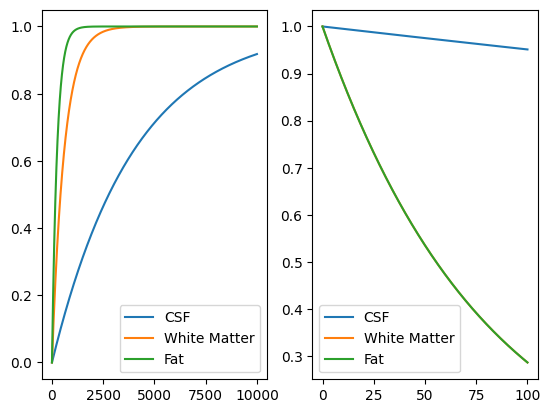

T1-Weighted
	CSF: 0.116 
	White Matter: 0.414 
	Fat: 0.633
T2-Weighted
	CSF: 0.679 
	White Matter: 0.286 
	Fat: 0.287
PD-Weighted
	CSF: 0.705 
	White Matter: 0.731 
	Fat: 0.732

Under T1 weighting, fat shows the brightest signal.  
      This is because it has the shortest T1 relaxation time, and so 
      has recovered its magnetisation the most by the time the measurement is taken.
Under T2 weighting, cerebrospinal fluid (CSF) shows the brightest signal.
      This is because it has the longest T2 degradation time, and so
      has decayed its magnetisation the least by the time the measurement is taken.
Under PD weighting, fat and white matter both show the brightest signal.
      This is because they have exactly the same T2 characteristic.
      Both of them have a shorter T1 and T2 relaxation time compared to CSF, but
      CSF's T1 relaxation is extremely long, so the imaging shows a difference.
      Conceptually, this indicates that fat and white matter have a higher
      den

In [5]:
print("=== Coding Exercise 1: Relaxation and Contrast Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0

def mz_recovery(time_ms, t1_ms, m0=1.0):
    return m0 * (1 - np.exp(-time_ms / t1_ms))


def mxy_decay(time_ms, t2_ms, mxy0=1.0):
    return mxy0 * np.exp(-time_ms / t2_ms)


def spin_echo_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


# TODO 1: Define the tissue dictionary.
tissue_dict = {
    "CSF" : {
        "T1" : 4000,
        "T2" : 2000
    },
    "White Matter" : {
        "T1" : 600,
        "T2" : 80
    },
    "Fat" : {
        "T1" : 250,
        "T2" : 80
    },
}


# TODO 2: Create time axes for T1 recovery and T2 decay.
time_1 = np.linspace(0, 10000, 10000)
time_2 = np.linspace(0, 100, 10000)

# TODO 3: Compute Mz(t) and Mxy(t) for each tissue.
mz_csf = mz_recovery(time_1, tissue_dict["CSF"]["T1"], M0)
mz_white_matter = mz_recovery(time_1, tissue_dict["White Matter"]["T1"], M0)
mz_fat = mz_recovery(time_1, tissue_dict["Fat"]["T1"], M0)

mxy_csf = mxy_decay(time_2, tissue_dict["CSF"]["T2"], M0)
mxy_white_matter = mxy_decay(time_2, tissue_dict["White Matter"]["T2"], M0)
mxy_fat = mxy_decay(time_2, tissue_dict["Fat"]["T2"], M0)

# TODO 4: Plot the T1 recovery and T2 decay curves.
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(time_1, mz_csf, time_1, mz_white_matter, time_1, mz_fat)
ax1.legend(["CSF", "White Matter", "Fat"])
ax2.plot(time_2, mxy_csf, time_2, mxy_white_matter, time_2, mxy_fat)
ax2.legend(["CSF", "White Matter", "Fat"])
plt.show()

# TODO 5: Define T1-, T2-, and PD-weighted (TR, TE) settings.
signal_weightings = {
    "T1-Weighted" : {
        "TR" : 500,
        "TE" : 25,
    }, 

    "T2-Weighted" : {
        "TR" : 5000,
        "TE" : 100,
    },   

    "PD-Weighted" : {
        "TR" : 5000,
        "TE" : 25,
    },  
}

# TODO 6: Compute the signal for each tissue under each weighting.
csf_signal_t1 = spin_echo_signal(signal_weightings["T1-Weighted"]["TR"],
                                signal_weightings["T1-Weighted"]["TE"],
                                tissue_dict["CSF"]["T1"],
                                tissue_dict["CSF"]["T2"])

white_matter_signal_t1 = spin_echo_signal(signal_weightings["T1-Weighted"]["TR"],
                                signal_weightings["T1-Weighted"]["TE"],
                                tissue_dict["White Matter"]["T1"],
                                tissue_dict["White Matter"]["T2"])

fat_signal_t1 = spin_echo_signal(signal_weightings["T1-Weighted"]["TR"],
                                signal_weightings["T1-Weighted"]["TE"],
                                tissue_dict["Fat"]["T1"],
                                tissue_dict["Fat"]["T2"])


csf_signal_t2 = spin_echo_signal(signal_weightings["T2-Weighted"]["TR"],
                                signal_weightings["T2-Weighted"]["TE"],
                                tissue_dict["CSF"]["T1"],
                                tissue_dict["CSF"]["T2"])

white_matter_signal_t2 = spin_echo_signal(signal_weightings["T2-Weighted"]["TR"],
                                signal_weightings["T2-Weighted"]["TE"],
                                tissue_dict["White Matter"]["T1"],
                                tissue_dict["White Matter"]["T2"])

fat_signal_t2 = spin_echo_signal(signal_weightings["T2-Weighted"]["TR"],
                                signal_weightings["T2-Weighted"]["TE"],
                                tissue_dict["Fat"]["T1"],
                                tissue_dict["Fat"]["T2"])

csf_signal_pd = spin_echo_signal(signal_weightings["PD-Weighted"]["TR"],
                                signal_weightings["PD-Weighted"]["TE"],
                                tissue_dict["CSF"]["T1"],
                                tissue_dict["CSF"]["T2"])

white_matter_signal_pd = spin_echo_signal(signal_weightings["PD-Weighted"]["TR"],
                                signal_weightings["PD-Weighted"]["TE"],
                                tissue_dict["White Matter"]["T1"],
                                tissue_dict["White Matter"]["T2"])

fat_signal_pd = spin_echo_signal(signal_weightings["PD-Weighted"]["TR"],
                                signal_weightings["PD-Weighted"]["TE"],
                                tissue_dict["Fat"]["T1"],
                                tissue_dict["Fat"]["T2"])

# TODO 7: Summarize the brightness ranking for each weighting.
print("T1-Weighted")
print("\tCSF:", round(csf_signal_t1, 3), "\n\tWhite Matter:", round(white_matter_signal_t1, 3), "\n\tFat:", round(fat_signal_t1, 3))
print("T2-Weighted")
print("\tCSF:", round(csf_signal_t2, 3), "\n\tWhite Matter:", round(white_matter_signal_t2, 3), "\n\tFat:", round(fat_signal_t2, 3))
print("PD-Weighted")
print("\tCSF:", round(csf_signal_pd, 3), "\n\tWhite Matter:", round(white_matter_signal_pd, 3), "\n\tFat:", round(fat_signal_pd, 3))

print('''
Under T1 weighting, fat shows the brightest signal.  
      This is because it has the shortest T1 relaxation time, and so 
      has recovered its magnetisation the most by the time the measurement is taken.
Under T2 weighting, cerebrospinal fluid (CSF) shows the brightest signal.
      This is because it has the longest T2 degradation time, and so
      has decayed its magnetisation the least by the time the measurement is taken.
Under PD weighting, fat and white matter both show the brightest signal.
      This is because they have exactly the same T2 characteristic.
      Both of them have a shorter T1 and T2 relaxation time compared to CSF, but
      CSF's T1 relaxation is extremely long, so the imaging shows a difference.
      Conceptually, this indicates that fat and white matter have a higher
      density of protons (hydrogen nuclei) than CSF does.
''')

## 1.3 Contrast Agent and Field-Strength Analysis

### **Questions 3**
A lesion has pre-contrast $T_{1,0}=1000$ ms. After gadolinium injection, assume
$R_1=1/T_1 = 1/T_{1,0} + r_1[C]$, with $r_1 = 4\ \mathrm{L\,mmol^{-1}\,s^{-1}}$ and $[C]=0.2\ \mathrm{mmol/L}$.

- a) Compute post-contrast $T_1$ and predict how the lesion signal changes on a T1-weighted image.

    $$T_1 = \left(\frac{1}{T_{1,0}} + r_1[C]\right)^{-1} = T_1 = \left(\frac{1}{1000\text{ ms}} + (4\ \mathrm{L\,mmol^{-1}\,s^{-1}} \times 0.2\ \mathrm{mmol/L})\right)^{-1}$$
    $$T_1 = \frac{1}{1800\text{ sec}^{-1}} = 555\text{ ms}$$

    The contrast-enhanced lesion has a significantly shorter T1, which means that it will appear much brighter on a T1-weighted image (as the Mz recovery is faster).

- b) Explain why lesion enhancement often suggests blood-brain barrier disruption, and name one intracranial structure that enhances normally.

    Gadolinium cannot ordinarily travel throgh the blood-brain barrier; thus, if lesions (even benign) behind is are enhanced, it signals that gadolinium has travelled through the barrier and thus that it has been disrupted.

    One intracranial structure that enhances with gadolinium, even if there is no disruption to the blood-brain barrier, is the pituitary gland (hypophysis); this structure is intracranial but is not protected by the blood-brain barrier, so gadolinium-based contrast agents may enhance it.

- c) Why must renal function be checked before gadolinium is given?

    Gadolinium is toxic to humans and has a strong tendency to bind with organic molecules (i.e. to chelate). Pre-chelated gadolinium can be ingested and used for MRI contrast, but if not excreted renally can still cause significant toxicity, and will remain in the body for a long time due to this chelation. Thus, to prevent these effects, it is important to ensure that renal functions are OK before administering gadolinium.

### **Questions 4**
At 3 T, many tissues show longer T1 values than at 1.5 T.

- a) Explain why a T1-weighted protocol copied directly from 1.5 T may not preserve the same contrast at 3 T.

    Since T1 values are typically longer when the magnetic field is larger, structures will take longer to recover their Mz magnetisations; since this recovery is exponential in nature and the 1.5T T1-weighted protocol is optimised to show the maximum T1 contrast, the relative contrast between them will be less at 3T. 
    
    In addition, the Larmor frequency of hydrogen is linearly proportional to the constant z-axis magnetic field; increasing this value increases the Larmor frequency, which consequently means that the same RF pulse will produce a larger flip angle. This means that (assuming the original protocol used a 90° flip angle), the Mz magnetisation will start at a greater-than-zero value, resulting in recovery starting from this value instead, which will further reduce the contrast.

- b) If you could change only one parameter first, would you adjust TR or flip angle? Defend your answer.

    I would adjust the flip angle first to ensure that the Mz magnetisation goes to zero, which will improve contrast the most compared to adjusting the TR; since the protocol is T1-weighted, using the same TR should still result in some non-insignificant contrast, assuming the flip angle is realigned with the new Larmor frequency.

- c) Give one important benefit and one important drawback of moving from 1.5 T to 3 T for routine MRI.

    One important benefit of increasing the static field strength of an MRI imaging system is that SNR increases roughly linearly with field strength, allowing for better imaging of small or low-resolution structures. 
    
    One major drawback, however, is that higher magnetic field imaging systems result in higher Larmor frequencies, which means that the RF pulse used to excite the hydrogen nuclei will need to be at a higher frequency. At high enough frequencies, the wavelength of this pulse approaches that of the body (microwave frequencies), which can cause heating and have implications for patient safety.

## 1.4 Contrast Agent and Field-Strength Simulation

### **Coding Exercise 2**
Build a compact simulation to study contrast-agent and field-strength effects.

Tasks:
1. Implement $\frac{1}{T_1}=\frac{1}{T_{1,0}}+r_1[C]$ and compute post-contrast $T_1$ for multiple concentrations.
2. Compare expected T1-weighted signal at 1.5 T and 3 T across a TR sweep.
3. Identify TR ranges that preserve lesion-to-background contrast.

**Helpful Note:** You can start from the values already given in **Question 3**, or choose your own reasonable values and state assumptions.

=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===


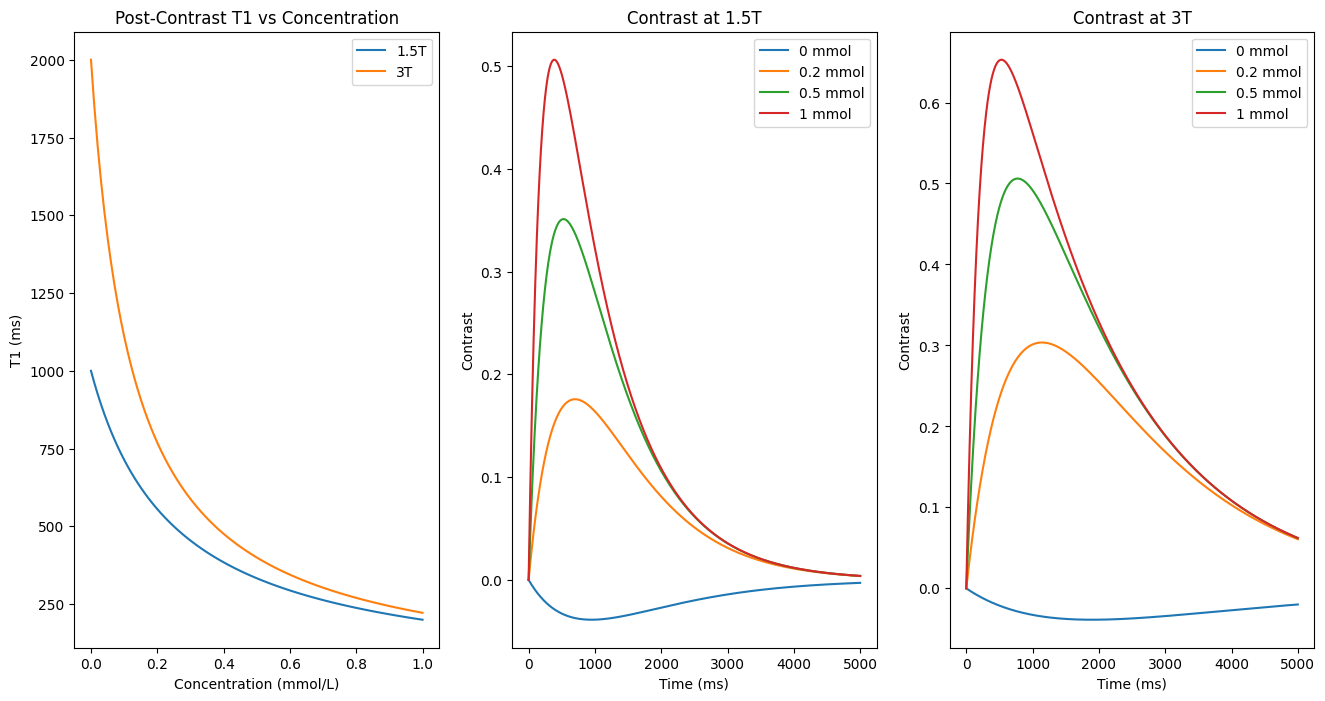

In [ ]:
print("=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

r1 = 4.0  # L mmol^-1 s^-1

def post_contrast_t1(t1_pre_ms, concentration_mmol_per_l, relaxivity=r1):
    t1_pre_s = t1_pre_ms / 1000.0
    r1_pre = 1.0 / t1_pre_s
    r1_post = r1_pre + relaxivity * concentration_mmol_per_l
    return 1000.0 / r1_post


def t1_weighted_signal(tr_ms, t1_ms):
    return 1 - np.exp(-tr_ms / t1_ms)


# TODO 1: Define baseline T1 values at 1.5 T and 3 T.
baseline_t1_1_5T = 1000 # ms (from Question 3)
baseline_t1_3T = 2000 # ms (since T1 is longer at higher field)

# TODO 2: Create a gadolinium concentration array.
gd_concentrations = np.linspace(0, 1, 100) # mmol/L

# TODO 3: Compute post-contrast lesion T1 for each field strength.
post_contrast_1_5T = [post_contrast_t1(baseline_t1_1_5T, concentration) for concentration in gd_concentrations]
post_contrast_3T = [post_contrast_t1(baseline_t1_3T, concentration) for concentration in gd_concentrations]

# TODO 4: Plot post-contrast lesion T1 versus concentration.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8))
ax1.plot(gd_concentrations, post_contrast_1_5T, gd_concentrations, post_contrast_3T)
ax1.legend(["1.5T", "3T"]); ax1.set_title("Post-Contrast T1 vs Concentration")
ax1.set_xlabel("Concentration (mmol/L)"); ax1.set_ylabel("T1 (ms)")

# TODO 5: Create a TR sweep.
tr_sweep = np.linspace(0, 5000, 1000) # ms

# TODO 6: Compute T1-weighted signal for lesion and background.

lesion_signal_1_5T_0mmol = [mz_recovery(tr, baseline_t1_1_5T) for tr in tr_sweep] 
lesion_signal_3T_0mmol = [mz_recovery(tr, baseline_t1_3T) for tr in tr_sweep] 

lesion_signal_1_5T_0_2mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_1_5T, 0.2)) for tr in tr_sweep] 
lesion_signal_3T_0_2mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_3T, 0.2)) for tr in tr_sweep] 

lesion_signal_1_5T_0_5mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_1_5T, 0.5)) for tr in tr_sweep] 
lesion_signal_3T_0_5mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_3T, 0.5)) for tr in tr_sweep] 

lesion_signal_1_5T_1mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_1_5T, 1)) for tr in tr_sweep] 
lesion_signal_3T_1mmol = [mz_recovery(tr, post_contrast_t1(baseline_t1_3T, 1)) for tr in tr_sweep] 

# per Lecture 25, typical T1 for muscle or grey matter (background) is close to 900 ms at 1.5T
# we will again assume a doubling of the T1 at 3T, so 1800 ms
background_T1_1_5T = 900 # ms
background_T1_3T = 1800 # ms

# using the function from Coding Exercise 1 (T1-weighted, so assume no effects from T2):
background_signal_1_5T = [mz_recovery(tr, background_T1_1_5T) for tr in tr_sweep] 
background_signal_3T = [mz_recovery(tr, background_T1_3T) for tr in tr_sweep] 

#ax2.plot(tr_sweep, background_signal_3T, tr_sweep, background_signal_1_5T)

# TODO 7: Compute lesion-background contrast.

def get_contrast(lesion_signal_sweep, background_signal_sweep):
    contrast = []
    for i, lesion_signal in enumerate(lesion_signal_sweep):
        contrast.append(lesion_signal - background_signal_sweep[i])
    return contrast

contrast__1_5T_0mmol = get_contrast(lesion_signal_1_5T_0mmol, background_signal_1_5T)
contrast__3T_0mmol = get_contrast(lesion_signal_3T_0mmol, background_signal_3T)

contrast__1_5T_0_2mmol = get_contrast(lesion_signal_1_5T_0_2mmol, background_signal_1_5T)
contrast__3T_0_2mmol = get_contrast(lesion_signal_3T_0_2mmol, background_signal_3T)

contrast__1_5T_0_5mmol = get_contrast(lesion_signal_1_5T_0_5mmol, background_signal_1_5T)
contrast__3T_0_5mmol = get_contrast(lesion_signal_3T_0_5mmol, background_signal_3T)

contrast__1_5T_1mmol = get_contrast(lesion_signal_1_5T_1mmol, background_signal_1_5T)
contrast__3T_1mmol = get_contrast(lesion_signal_3T_1mmol, background_signal_3T)

# TODO 8: Plot the signal or contrast versus TR.

ax2.plot(tr_sweep, contrast__1_5T_0mmol,
    tr_sweep, contrast__1_5T_0_2mmol,
    tr_sweep, contrast__1_5T_0_5mmol,
    tr_sweep, contrast__1_5T_1mmol)
ax2.set_title("Contrast at 1.5T")
ax2.set_xlabel("Time (ms)"); ax2.set_ylabel("Contrast")
ax2.legend(["0 mmol", "0.2 mmol", "0.5 mmol", "1 mmol"])

ax3.plot(tr_sweep, contrast__3T_0mmol,
    tr_sweep, contrast__3T_0_2mmol,
    tr_sweep, contrast__3T_0_5mmol,
    tr_sweep, contrast__3T_1mmol,)
ax3.set_title("Contrast at 3T")
ax3.set_xlabel("Time (ms)"); ax3.set_ylabel("Contrast")
ax3.legend(["0 mmol", "0.2 mmol", "0.5 mmol", "1 mmol"])

plt.show()

# TODO 9: Add a short note about SAR at 3 T.
'''
The Specific Absorption Rate (SAR), measured in W/kg,
measures the absorption of magnetic field energy into
the body. It is proportional to the square of the 
primary coil magnetic field, so a 3 T field would have 
4 times the SAR of a 1.5 T field (twice the field 
strength). A SAR of 1 W/kg would heat a patient by
approximately 1ºC per hour (depending on body part),
so 3T scanning can be more dangerous and requires
either fewer or lower-frequency RF pulses
(or using imaging modes with a lower flip angle)
to have the same amount of tissue heating as at 1.5T.
'''

---

# Part 2: Spatial Encoding, Gradients, and k-Space

## Key Concepts

**Magnetic Field Gradients:**
- Spatially varying field: $B(x)=B_0+G_xx$
- Position-dependent frequency: $\omega(x)=\gamma(B_0+G_xx)$

**Slice Selection:**
- Apply gradient during RF pulse
- Slice thickness: $\Delta z=\frac{BW}{\gamma G_z}$
- Thinner slices: increase $G_z$ or reduce RF bandwidth

**In-Plane Encoding:**
- Frequency encoding during readout gradient
- Phase encoding via gradient before readout
- Scan time is largely driven by number of phase-encode steps

**k-Space:**
- Spatial frequency domain of MRI data
- Image = Fourier transform of k-space
- Center of k-space controls contrast/intensity; edges control detail/resolution

## 2.1 Slice Selection and Encoding Calculations

### **Questions 5**
You apply a slice-selection gradient of $G_z=12\ \mathrm{mT/m}$ with RF bandwidth $BW=2.4\ \mathrm{kHz}$.

- a) Calculate slice thickness $\Delta z$ using $\gamma=42.58\ \mathrm{MHz/T}$.

    Slice thickness for this gradient is calculated:
$$\Delta z=\frac{BW}{\gamma G_z} = \frac{2.4\ \mathrm{kHz}}{42.58\ \mathrm{MHz/T} \times 12\ \mathrm{mT/m}} = 4.6\ \mathrm{mm}$$

- b) If $G_z$ doubles or BW halves, what happens to slice thickness in each case?

    Slice thickness is directly inversely proportional to the z-gradient, doubling the gradient magnitude will halve the slice thickness (i.e. the slice will be twice as thin as previously).
    
    Since slice thickness is directly proportional to the bandwidth, halving the bandwidth will also halve the slice thickness.

- c) Which change is usually the more practical way to make slices thinner, and what trade-off comes with it?

    It is typically more practical to increase the gradient slope rather than reducing the bandwidth of the RF pulse; however, high gradients increase the amount of peripheral nerve stimulation (running the risk of affecting cardiac nerves if the gradient is too high) as well as the amount of auditory noise in the MRI machine (necessitating ear protection for the patient).

- d) Explain why thinner slices improve anatomical detail but make imaging harder from an SNR or motion standpoint.

    Reducing slice thickness directly improves spatial resolution along the gradient axis, as thinner structures along that axis can now be resolved. The tradeoff for this, however, is that due to fewer atoms being excited, the received RF signal will be weaker and thus more affected by noise (decreasing SNR). In addition, if multiple slices must be imaged, the scan will take longer, increasing the risk of motion artifacts being introduced from patient or organ motion. 

### **Questions 6**
A 2D sequence uses $TR=2500$ ms, $N_{PE}=192$, and $NEX=2$.

- a) Compute total scan time.

    The total scan time is equal to $TR \times N_{PE} \times NEX = 2500$ ms $\times 192 \times 2 = 960$ seconds.

- b) If $N_{PE}$ is reduced to 128, what is the new scan time?

    $TR \times N_{PE} \times NEX = 2500$ ms $\times 128 \times 2 = 640$ seconds.

- c) Compare reducing scan time by lowering NEX versus lowering $N_{PE}$. Which costs SNR, and which costs spatial resolution?

    Reducing the number of exposures ($NEX$) retains the spatial resolution, but decreases the SNR of the imaging system because less total RF signal will be detected.

    On the other hand, reducing the number of phase encodes ($N_{PE}$) will keep the same SNR, since each phase encode will have two exposures, but reduce the spatial resolution in the phase encode direction due to having fewer scanlines.


## 2.2 k-Space Exploration and Fourier Reconstruction

### **Coding Exercise 3**
Use `IMG-0002-00001.dcm` to explore k-space concepts and reconstruction.

Tasks:
1. Load `IMG-0002-00001.dcm` and use the slice viewer to inspect the stack.
2. Move the slider to choose one slice from the middle portion of the stack that shows clear anatomy boundaries and relatively little empty background. Record the slice index.
3. Rerun the cell after choosing your slice so the analysis below uses that selected image.
4. Compute its 2D Fourier transform (k-space).
5. Visualize the image and k-space magnitude (log scale).
6. Reconstruct the image using the inverse Fourier transform.
7. Demonstrate the effect of:
   - Keeping only central k-space (low-pass behavior)
   - Removing central k-space (high-pass/edge emphasis)
   - Truncating high-frequency corners
8. Explain how these manipulations affect contrast and spatial detail.

**Helpful Note:** This exercise is a direct application of **Lecture 26**. Use the ideas that the center of k-space controls broad contrast and brightness, the outer regions control fine detail, and image reconstruction uses the 2D inverse Fourier transform.

=== Coding Exercise 3: k-Space and Reconstruction ===


HTML(value='<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion with clear anatomy …

IntSlider(value=8, continuous_update=False, description='Slice', layout=Layout(width='450px'), max=20)

HTML(value='')

Output()

Using slice index 8 for k-space analysis.


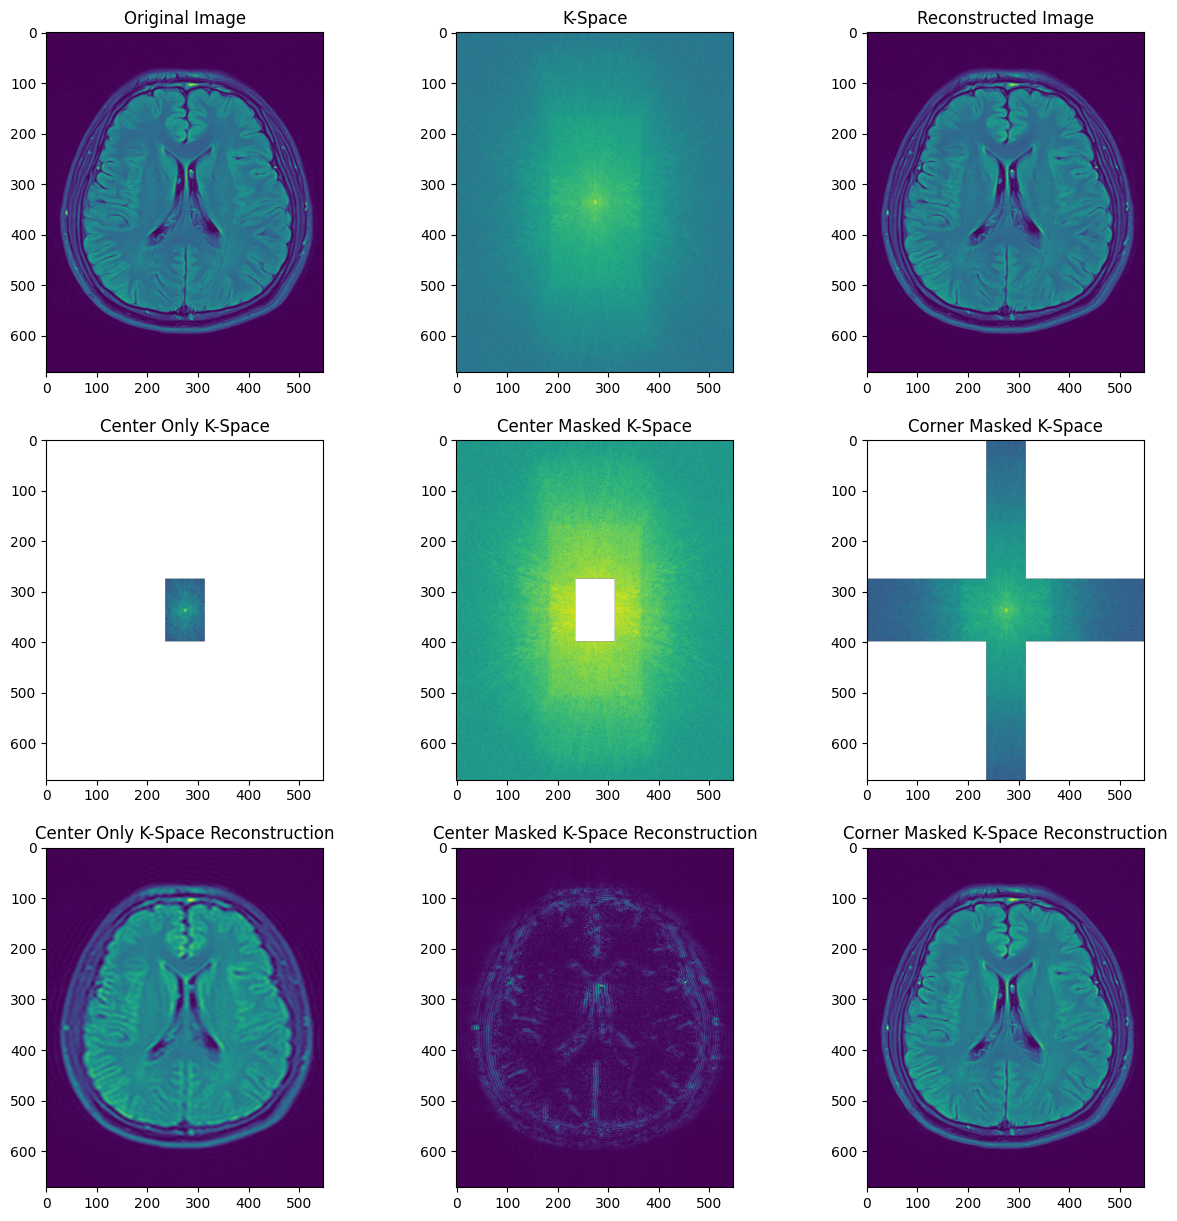


Using only the centre of the k-space to reconstruct the original image,
we can see that the reconstruction appears to be a blurry version of the
true image. This makes sense; we are keeping only the low spatial
frequencies and discarding the high ones, so in effect we have created
a spatial lowpass filter. The overall image contrast is kept,
but the spatial detail is somewhat degraded.

Similarly, using only the non-central areas, we have done the opposite:
created a spatial highpass filter! This time, the overall image contrast
(from the center) is lost, but the spatial detail's contrast is increased
significantly. 

Important note: using a mask like this will produce some spatial 
'ringing', since the IFFT of a box function is a sinc function. This
is not super obvious in these images, but if the mask were smaller we
would see significant artifiacts being introduced to the lowpassed image.

Truncating the corners of the image produces a reconstruction which
seems to match the origin

In [82]:
print("=== Coding Exercise 3: k-Space and Reconstruction ===")

from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    #%pip install ipywidgets
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    #%pip install pydicom
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to your example DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("DICOMS/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


def set_selected_slice(slice_idx: int):
    slice_idx = int(max(0, min(slice_stack.shape[0] - 1, slice_idx)))
    globals()["selected_slice_idx"] = slice_idx
    globals()["image"] = normalize_image(slice_stack[slice_idx])
    selection_message.value = (
        f"<b>Current selected slice:</b> {slice_idx}. "
        "If you change the slider, rerun this cell or Coding Exercise 4 to use the updated slice."
    )


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
default_slice_idx = slice_stack.shape[0] // 2
selected_slice_idx = int(globals().get("selected_slice_idx", default_slice_idx))
selection_message = widgets.HTML()


def render_slice(slice_idx: int):
    preview = normalize_image(slice_stack[slice_idx])
    plt.figure(figsize=(6, 6))
    plt.imshow(preview, cmap="gray")
    plt.title(f"IMG-0002-00001.dcm | slice {slice_idx}/{slice_stack.shape[0] - 1}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if slice_stack.shape[0] > 1:
    slice_slider = widgets.IntSlider(
        min=0,
        max=slice_stack.shape[0] - 1,
        step=1,
        value=selected_slice_idx,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )

    def on_slice_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        set_selected_slice(change["new"])

    slice_slider.observe(on_slice_change, names="value")
    display(widgets.HTML(
        "<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion "
        "with clear anatomy boundaries and minimal empty background."
    ))
    display(slice_slider)
    display(selection_message)
    display(widgets.interactive_output(render_slice, {"slice_idx": slice_slider}))
    set_selected_slice(slice_slider.value)
else:
    render_slice(default_slice_idx)
    set_selected_slice(default_slice_idx)

image = globals()["image"]
print(f"Using slice index {int(globals()['selected_slice_idx'])} for k-space analysis.")

# TODO: Compute 2D FFT and shift zero-frequency to center.
k_space = np.fft.fftshift(np.fft.fft2(image))

# TODO: Visualize the source image and log-magnitude k-space.
fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes[0][0].imshow(image)
axes[0][0].set_title("Original Image")
axes[0][1].imshow(np.log(np.abs(k_space)))
axes[0][1].set_title("K-Space")

# TODO: Reconstruct image with inverse FFT.
axes[0][2].imshow(np.abs(np.fft.ifft2(k_space)))
axes[0][2].set_title("Reconstructed Image")

# TODO: Apply central-k-space, no-center, and corner-truncation masks.

k_space_rows = k_space.shape[0]
k_space_cols = k_space.shape[1]

center_only_k_space = k_space.copy()
center_masked_k_space = k_space.copy()
corner_masked_k_space = k_space.copy()

mask_x_edge = int(0.5*k_space_cols)
mask_y_edge = int(0.35*k_space_rows)

# remove the center mask
center_masked_k_space[mask_x_edge : -mask_x_edge, mask_y_edge : -mask_y_edge] = 0 

# remove all but the center mask
center_only_k_space[0 : mask_x_edge] = 0 
center_only_k_space[: , 0: mask_y_edge] = 0 
center_only_k_space[-mask_x_edge : ] = 0 
center_only_k_space[: , -mask_y_edge : ] = 0 

# remove only the corners
corner_masked_k_space[0 : mask_x_edge, 0 : mask_y_edge] = 0
corner_masked_k_space[0 : mask_x_edge, -mask_y_edge : ] = 0
corner_masked_k_space[-mask_x_edge : , -mask_y_edge : ] = 0
corner_masked_k_space[-mask_x_edge : , 0 : mask_y_edge] = 0

with np.errstate(divide='ignore'): # log() ignores masked areas already; silence the warnings
    axes[1][0].imshow(np.log(np.abs(center_only_k_space)))
    axes[1][0].set_title("Center Only K-Space")
    axes[1][1].imshow(np.log(np.abs(center_masked_k_space)))
    axes[1][1].set_title("Center Masked K-Space")
    axes[1][2].imshow(np.log(np.abs(corner_masked_k_space)))
    axes[1][2].set_title("Corner Masked K-Space")

axes[2][0].imshow(np.abs(np.fft.ifft2(center_only_k_space)))
axes[2][0].set_title("Center Only K-Space Reconstruction")
axes[2][1].imshow(np.abs(np.fft.ifft2(center_masked_k_space)))
axes[2][1].set_title("Center Masked K-Space Reconstruction")
axes[2][2].imshow(np.abs(np.fft.ifft2(corner_masked_k_space)))
axes[2][2].set_title("Corner Masked K-Space Reconstruction")

plt.show()

# TODO: Compare reconstructions and discuss contrast/detail differences.
print('''
Using only the centre of the k-space to reconstruct the original image,
we can see that the reconstruction appears to be a blurry version of the
true image. This makes sense; we are keeping only the low spatial
frequencies and discarding the high ones, so in effect we have created
a spatial lowpass filter. The overall image contrast is kept,
but the spatial detail is somewhat degraded.

Similarly, using only the non-central areas, we have done the opposite:
created a spatial highpass filter! This time, the overall image contrast
(from the center) is lost, but the spatial detail's contrast is increased
significantly. 

Important note: using a mask like this will produce some spatial 
'ringing', since the IFFT of a box function is a sinc function. This
is not super obvious in these images, but if the mask were smaller we
would see significant artifiacts being introduced to the lowpassed image.

Truncating the corners of the image produces a reconstruction which
seems to match the original image very closely, without much loss of
overall contrast or spatial detail. This makes sense; these very
high-frequency components are also extremely low in amplitude,
so they do not significantly contribute to the overall image. 
Even so, we would expect some small details to be lost.
''')

## 2.3 Gradient History and k-Space Trajectory

### **Questions 7**
Consider Cartesian k-space sampling in a 2D GRE sequence.

- a) Explain why each TR usually acquires one readout line but a different $k_y$ value.

    The output signal from a single TR of the output image is a single RF pulse. Because the $ky$ direction is phase-encoded instead of frequency-encoded, the phase data can only be identified by taking multiple pulses with different y gradients and comparing the amplitudes at each frequency to identify the contributions of each structure along the y-axis. Each pulse necessitates one instance of TR.

- b) Relate k-space spacing to FOV and k-space extent to spatial resolution.

    The field of view (FOV) of the overall MRI imageis given by $FOV = \frac{1}{\Delta k}$, where $\Delta k$ is the spatial difference between each data point in k-space.

    Meanwhile, the spatial resolution is given by  $\Delta x = \frac{FOV_x}{N_x}$, where $N$ is the number of samples taken in the $x$ direction. (Resolution in the other axes uses the same formula with $x$ substituted for $y$ or $z$.) Since we know that $FOV = \frac{1}{\Delta k}$, it follows that $\Delta x = \frac{1}{\Delta k_x \times N_x}$, or in other words, the spatial resolution is the inverse of the physical extent of k-space across that axis (the spacing between samples times the number of samples).

- c) Why does undersampling in the phase-encode direction produce wrap-around?

    Wrap-around, or aliasing, occurs when objects outside the FOV of the phase-encode axis appear erroneously within the FOV of the image. This happens because of undersampling in the phase-encode direction; since $3\pi$ radians of phase is equivalent to $\pi$ radians of phase, the system mistakes the former for the latter; better sampling of the spatial region would reduce the appearance of these errors.

### **Questions 8**
Compare Cartesian and non-Cartesian trajectories such as radial or spiral.

- a) Which trajectories oversample the center of k-space, and why can that help with motion?
- b) What extra reconstruction challenge appears when sampling is non-uniform?
- c) Give one clinical situation where a radial or spiral trajectory could be preferred, and justify your choice.


## 2.4 Undersampling and Acquisition Efficiency

### **Coding Exercise 4**
Reuse the same selected slice from `IMG-0002-00001.dcm` to compare encoding choices and acquisition efficiency.

Tasks:
1. Use the same slice index selected in Coding Exercise 3. If you change the slider in Coding Exercise 3, rerun this cell so it uses the updated slice. If you did not run Exercise 3, the middle slice will be used by default.
2. Implement scan-time estimates for multiple protocol options (TR, N_PE, NEX, ETL).
3. Create at least two undersampling patterns (for example, uniform skip and central-weighted retention).
4. Reconstruct from each sampling pattern and compare artifact severity.
5. Summarize the best speed-vs-quality option for a chosen clinical objective.

In [40]:
#Run this cell to verify the slice viewer is working for the next coding exercises.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to correct DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("DICOMS/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
slice_idx = int(globals().get("selected_slice_idx", slice_stack.shape[0] // 2))
slice_idx = max(0, min(slice_stack.shape[0] - 1, slice_idx))
reference_image = normalize_image(slice_stack[slice_idx])

print(f"Using slice index {slice_idx} for encoding comparisons.")


Using slice index 8 for encoding comparisons.


In [ ]:
print("=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===")

# TODO 1: Define protocol settings and estimate scan time.

# TODO 2: Compute k-space from the reference image.

# TODO 3: Create at least two undersampling masks.

# TODO 4: Reconstruct images for each mask.

# TODO 5: Compare image quality and speed.

# TODO 6: Recommend one acquisition strategy.
# ...

=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===


---

# Part 3: Pulse Sequences and Image Weighting Strategies

## Key Concepts

**Gradient Echo (GRE):**
- Uses gradient reversal (no 180° RF pulse)
- Fast imaging, short TR/TE possible
- T2* sensitive (susceptibility effects prominent)

**Spin Echo (SE):**
- Uses 90° + 180° refocusing pulse
- Refocuses static inhomogeneity dephasing
- Produces true T2 contrast

**Fast Spin Echo (FSE/TSE):**
- Multiple echoes per TR (echo train length, ETL)
- Greatly reduces scan time
- Long ETL may introduce T2 blurring

**Inversion Recovery (STIR/FLAIR):**
- Inversion pulse + TI to null specific tissue
- STIR suppresses short-T1 tissues (fat)
- FLAIR suppresses CSF for brain lesion conspicuity

## 3.1 Sequence Selection and Parameter Trade-offs

### **Questions 9**
You need to image a lesion near the paranasal sinuses, where susceptibility effects are strong.

- a) Would GRE or SE better preserve lesion signal? Explain using susceptibility and $T_2^*$ ideas.
- b) If signal dropout is still a problem, would you shorten TE or change sequence family first? Defend your answer.
- c) Why can GRE still be the right choice for some fast 3D exams even in susceptibility-prone regions?

### **Questions 10**
An FSE sequence uses $TR=4000$ ms, $N_{PE}=256$, and $NEX=1$.

- a) Compute scan time for standard SE ($ETL = 1$), FSE with $ETL = 8$, and FSE with $ETL = 16$.
- b) Why does long ETL reduce image sharpness?
- c) For a routine T2-weighted brain exam, what ETL range would you choose, and why?


## 3.2 Sequence Timing and Contrast Simulator

### **Coding Exercise 5**
Build a simplified MRI sequence simulator to compare contrast behavior across GRE, SE, and IR-style timing.

Tasks:
1. Define representative tissue parameters ($T_1$, $T_2$, $T_2^*$).
2. Implement simplified signal models:
   - GRE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2^*}$
   - SE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2}$
   - IR (long TR approximation): $M_z(TI)=M_0(1-2e^{-TI/T_1})$
3. Sweep TE and TR, and visualize signal trends.
4. Demonstrate tissue nulling with TI (e.g., STIR-like fat suppression, FLAIR-like CSF suppression).
5. Interpret which parameter combinations best match each intended weighting.

**Helpful Note:** Review **Lecture 27** notes on GRE/SE and inversion recovery (STIR/FLAIR). You can also use the scan-time discussion in **Question 10** and the null-TI idea in **Question 11** to guide your interpretation.

In [ ]:
print("=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0


def gre_signal(tr_ms, te_ms, t1_ms, t2star_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2star_ms)


def se_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


# TODO 1: Define tissue parameters.

# TODO 2: Create TR, TE, and TI sweeps.

# TODO 3: Compute GRE and SE signal trends.

# TODO 4: Plot GRE and SE signal behavior.

# TODO 5: Compute inversion-recovery curves across TI.

# TODO 6: Estimate STIR-like and FLAIR-like null times.

# TODO 7: Add a short interpretation of the contrast behavior.

# ...

=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===


## 3.3 Inversion Recovery Case Analysis

### **Questions 11**
You are selecting between STIR and FLAIR for two clinical applications.

- a) For edema near fat and for periventricular brain lesions, which sequence would you choose in each case, and why?
- b) Using $TI_{null} \approx T_1\ln 2$, estimate the null TI for fat with $T_1 = 250$ ms and for CSF with $T_1 = 4000$ ms.
- c) Why is STIR generally avoided after gadolinium enhancement?

### **Questions 12**
A protocol engineer proposes replacing all SE scans with GRE to reduce scan time.

- a) Give three clinical situations where this would be a poor choice.
- b) Propose a mixed GRE and SE/FSE protocol strategy, and justify it.
- c) Name one hardware or safety issue that also argues against relying on only one sequence family.


## 3.4 Inversion Recovery and Echo-Train Trade-off Simulation

### **Coding Exercise 6**
Implement a simulation that links inversion recovery behavior with FSE timing trade-offs.

Tasks:
1. Compute $M_z(TI)=M_0(1-2e^{-TI/T_1})$ for fat-like and CSF-like tissues.
2. Estimate TI values that null each tissue class.
3. Simulate scan-time changes for ETL = 1, 8, 16, 24 using fixed TR and $N_{PE}$.
4. Build a short decision table: when to prioritize STIR/FLAIR contrast vs faster FSE acquisition.

**Helpful Note:** You can use **Question 11** values directly for fat and CSF. Review **Lecture 27** notes on inversion recovery and FSE/ETL trade-offs.

In [ ]:
print("=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===")

import numpy as np

M0 = 1.0

def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


def estimate_scan_time_seconds(tr_ms, n_pe, nex, etl):
    etl = max(1, int(etl))
    return (tr_ms / 1000.0) * (n_pe / etl) * nex


# TODO 1: Define T1 values for fat-like and CSF-like tissues.

# TODO 2: Create a TI sweep.

# TODO 3: Compute Mz(TI) and identify the null point for each tissue.

# TODO 4: Summarize the null TI values.

# TODO 5: Compute scan times for ETL = 1, 8, 16, 24.

# TODO 6: Build a short comparison table or list.

# TODO 7: Add a short decision summary.

# ...

=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===


---

# Part 4: Advanced MRI, Artifacts, and Safety

## Key Concepts

**Diffusion-Weighted Imaging (DWI):**
- Sensitive to Brownian motion of water
- Signal model: $S=S_0e^{-bD}$
- Restricted diffusion appears bright on DWI and dark on ADC maps

**Echo Planar Imaging (EPI):**
- Very fast acquisition (often one excitation)
- Enables DWI/fMRI but is prone to distortion and ghosting

**Common Artifacts:**
- Motion ghosting (phase-encode direction)
- Aliasing/wrap-around (insufficient FOV)
- Chemical shift (fat-water frequency mismatch)
- Susceptibility distortion/signal loss (metal, air interfaces)
- Gibbs/truncation ringing (finite k-space sampling)

**MRI Safety Domains:**
- Static field hazards (projectiles, implants)
- RF heating and SAR limits
- Gradient hazards (PNS, acoustic noise)
- Strict screening and zone control are essential

## 4.1 Diffusion and EPI Interpretation

### **Questions 13**
A patient with acute neurologic deficit has:
- DWI: focal bright signal in right MCA territory
- ADC map: corresponding dark region

- a) Interpret this finding physiologically, and explain why DWI can detect acute ischemia earlier than CT.
- b) What is T2 shine-through, and how does the ADC map help distinguish it from true restricted diffusion?
- c) Why is EPI commonly used for DWI even though it is sensitive to distortion?

### **Questions 14**
Given $S=S_0e^{-bD}$, compare expected diffusion signal for:
- Tissue X: $D=0.4\times10^{-3}\ \mathrm{mm^2/s}$
- Tissue Y: $D=1.0\times10^{-3}\ \mathrm{mm^2/s}$
for $b=1000\ \mathrm{s/mm^2}$.

- a) Compute normalized signals $S/S_0$ for both tissues.
- b) Which tissue appears brighter on high-b DWI, and why?
- c) What is gained and what is lost when b-value is increased?
- d) Why are at least two b-values needed for ADC, and why are more than two often useful?


## 4.2 DICOM Slice Navigation and Display-Window Analysis

### **Coding Exercise 7**
Use the DICOM slice viewer to study how display settings affect what anatomy is visible. The DICOM folder contains **6 series from a right knee MRI exam**. Use the table below to orient yourself before choosing a series:

| Series | Weighting | Plane |
|--------|-----------|-------|
| `series-000001` | Proton density | Axial |
| `series-000002` | Proton density | Coronal |
| `series-000003` | T1-weighted | Coronal |
| `series-000004` | Localizer only | Multi |
| `series-000005` | PD + fat suppression | Sagittal |
| `series-000006` | T2-weighted | Sagittal |

**Note:** `series-000004` is a quick scout/localizer used for planning — it has very low contrast and is not useful for this exercise. Choose any of the other five series.

**PART A: Choose your data**
1. Pick **one series** from the dropdown.
2. Select **3 slice indices** from that series, spread across the stack (early, middle, late).
3. Record your 3 chosen slice numbers.

**PART B: Compare display settings**
For each of the 3 slices, evaluate all three settings below:
1. **Baseline:** Low % = 2, High % = 98
2. **Higher contrast:** Low % = 10, High % = 90
3. **Wider range:** Low % = 1, High % = 99

**PART C: Required output figure**
1. Create one figure arranged as **3 rows × 3 columns**:
   - Rows = your 3 selected slice indices
   - Columns = the 3 display settings above
2. Add clear titles/labels with slice index and (% low, % high).

**PART D: Short analysis**
1. For each slice, choose the setting that best shows anatomy boundaries.
2. Briefly state what became easier/harder to see as you changed % settings.
3. Explain in 3-5 sentences why changing Low%/High% changes visibility even though underlying pixel data is unchanged.

In [ ]:
# Run this cell to load the slice viewer for the next coding exercises.

from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc


def find_dicom_root() -> Path:
    # Update this path to point to your own "DICOMS" folder location.
    # Example: Path("/Users/yourname/Desktop/DICOMS")

    dicom_path = Path("DICOMS") # Update this if needed

    if dicom_path.exists() and dicom_path.is_dir():
        return dicom_path

    raise FileNotFoundError(
        "Could not find the DICOMS folder. Please update the path to your local DICOMS directory."
    )

def dicom_sort_key(ds, path: Path):
    instance_number = getattr(ds, "InstanceNumber", None)
    if instance_number is not None:
        try:
            return (0, int(instance_number))
        except Exception:
            pass

    position = getattr(ds, "ImagePositionPatient", None)
    if position is not None:
        try:
            return (1, float(position[-1]))
        except Exception:
            pass

    return (2, path.name)


def load_series(series_dir: Path):
    dicom_paths = sorted(series_dir.glob("*.dcm"))
    if not dicom_paths:
        raise ValueError(f"No DICOM files found in {series_dir}")

    slice_records = []
    for dicom_path in dicom_paths:
        ds = pydicom.dcmread(dicom_path)
        pixel_array = ds.pixel_array.astype(np.float32)
        slice_records.append((dicom_sort_key(ds, dicom_path), pixel_array))

    slice_records.sort(key=lambda item: item[0])
    return np.stack([record[1] for record in slice_records], axis=0)


def window_image(image: np.ndarray, low_pct: int = 2, high_pct: int = 98):
    low_pct = max(0, min(99, low_pct))
    high_pct = max(low_pct + 1, min(100, high_pct))

    lo, hi = np.percentile(image, (low_pct, high_pct))
    if np.isclose(lo, hi):
        lo = float(np.min(image))
        hi = float(np.max(image))
        if np.isclose(lo, hi):
            hi = lo + 1.0

    return np.clip(image, lo, hi), float(lo), float(hi)


def create_slice_viewer(series_data: dict):
    series_names = sorted(series_data.keys())
    default_series = series_names[0]
    default_volume = series_data[default_series]

    series_dropdown = widgets.Dropdown(
        options=series_names,
        value=default_series,
        description="Series",
        layout=widgets.Layout(width="300px"),
    )
    slice_slider = widgets.IntSlider(
        min=0,
        max=default_volume.shape[0] - 1,
        step=1,
        value=default_volume.shape[0] // 2,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )
    low_slider = widgets.IntSlider(
        min=0,
        max=30,
        step=1,
        value=2,
        description="Low %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )
    high_slider = widgets.IntSlider(
        min=70,
        max=100,
        step=1,
        value=98,
        description="High %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )

    def on_series_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        volume = series_data[change["new"]]
        slice_slider.max = volume.shape[0] - 1
        slice_slider.value = volume.shape[0] // 2

    series_dropdown.observe(on_series_change, names="value")

    def render(series_name, slice_idx, low_pct, high_pct):
        volume = series_data[series_name]
        image = volume[slice_idx]
        image_disp, lo, hi = window_image(image, low_pct, high_pct)

        plt.figure(figsize=(6, 6))
        plt.imshow(image_disp, cmap="gray", vmin=lo, vmax=hi)
        plt.title(f"{series_name} | slice {slice_idx}/{volume.shape[0] - 1}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    controls = {
        "series_name": series_dropdown,
        "slice_idx": slice_slider,
        "low_pct": low_slider,
        "high_pct": high_slider,
    }

    viewer_output = widgets.interactive_output(render, controls)
    ui = widgets.VBox([
        widgets.HTML("<b>Interactive DICOM Slice Viewer</b>"),
        widgets.HBox([series_dropdown, slice_slider]),
        widgets.HBox([low_slider, high_slider]),
        viewer_output,
    ])
    display(ui)


# Load DICOM series and launch the slice viewer
dicom_root = find_dicom_root()
series_dirs = sorted([path for path in dicom_root.iterdir() if path.is_dir() and path.name.startswith("series-")])

if not series_dirs:
    raise ValueError(f"No series-* folders found under {dicom_root}")

series_data = {series_dir.name: load_series(series_dir) for series_dir in series_dirs}

create_slice_viewer(series_data)


In [ ]:
print("=== Coding Exercise 7: Windowing Comparison Figure ===")

# TODO 1: Choose one series and three slice indices.

# TODO 2: Define the three display settings.

# TODO 3: Build the 3 x 3 comparison figure.

# TODO 4: Add a short analysis of which setting best shows anatomy boundaries.
# ...

=== Coding Exercise 7: Windowing Comparison Figure ===


## 4.3 MRI Safety Scenario Analysis

### **Questions 15**
A patient arrives for MRI with uncertain implant documentation.

- a) Outline a safe decision pathway before scanning.
- b) Distinguish MR Safe, MR Conditional, and MR Unsafe, and explain why “the scanner is off” is not a valid safety assumption.
- c) If a medical emergency occurs in Zone IV, what should happen first and why?

### **Questions 16**
You are optimizing a high-field MRI protocol and observe elevated SAR estimates.

- a) List sequence choices that tend to increase SAR.
- b) Suggest practical protocol changes that reduce SAR while keeping the exam diagnostic.
- c) How are RF heating hazards different from gradient-related acoustic noise or PNS?
- d) Why are patient screening and in-scan monitoring still necessary even after protocol optimization?


## 4.4 Design Component: MRI Acquisition + Reconstruction

### **Coding Exercise 8**
In this design task, you will act like an MRI protocol designer for **one** clinical problem. Your goal is to choose a reasonable scan approach, show how the data would be acquired and reconstructed, and explain why your final design is a good choice.

### **Choose ONE scenario**
1. **Acute ischemic stroke detection**: focus on diffusion sensitivity and speed.
2. **Brain lesion near sinuses**: focus on reducing susceptibility-related signal loss and distortion.
3. **Musculoskeletal edema near fat**: focus on fluid sensitivity and fat suppression.

### **Part A — Protocol Definition**
Define the MRI protocol you would use.
1. Choose a sequence family and briefly explain why it fits the scenario.
2. Specify reasonable imaging parameters: TR, TE, TI (if used), flip angle, matrix, FOV, N_PE, NEX, ETL.
3. Estimate scan time and describe the expected image weighting or contrast.

### **Part B — Acquisition Strategy**
Explain how the data will be collected in k-space.
1. Choose a strategy such as full Cartesian, partial Fourier, accelerated undersampling, or a non-Cartesian option.
2. Explain what you expect to gain in speed.
3. Explain what artifact or image-quality risk this choice introduces.

### **Part C — Reconstruction and Comparison**
Show two versions of the reconstruction.
1. Create one **baseline reconstruction** using your standard approach.
2. Create one **alternative reconstruction** that is either faster or more robust.
3. Compare the two using at least one quantitative measure and a short qualitative comment.
4. State which version you would actually choose for this scenario.

### **Part D — Safety + Final Recommendation**
Finish with a clinically reasonable recommendation.
1. List safety issues that matter for your scenario (for example: SAR, implant screening, static-field concerns, acoustic noise, or PNS).
2. Give a final recommendation that clearly states:
   - which protocol you would use
   - why it fits the clinical problem
   - what trade-off you are accepting

 **Helpful Note:** You may reuse a reference image from earlier coding exercises, or use your own/synthetic image and state assumptions.

In [ ]:
print("=== Coding Exercise 8: MRI Design Component ===")

import matplotlib.pyplot as plt
import numpy as np


def estimate_scan_time_seconds(protocol):
    etl = max(1, int(protocol.get("ETL", 1) or 1))
    return (protocol["TR_ms"] / 1000.0) * (protocol["N_PE"] / etl) * protocol["NEX"]


def get_reference_image():
    if "reference_image" in globals():
        return reference_image
    if "image" in globals():
        return image

    rows, cols = 256, 256
    rr, cc = np.ogrid[:rows, :cols]
    phantom = np.zeros((rows, cols), dtype=np.float32)
    body_mask = ((rr - rows / 2) ** 2) / (70 ** 2) + ((cc - cols / 2) ** 2) / (95 ** 2) <= 1
    lesion_mask = ((rr - rows / 2 + 18) ** 2) / (16 ** 2) + ((cc - cols / 2 - 10) ** 2) / (20 ** 2) <= 1
    phantom[body_mask] = 0.75
    phantom[lesion_mask] = 1.0
    return phantom


def reconstruct_from_mask(image_2d, mask):
    kspace = np.fft.fftshift(np.fft.fft2(image_2d))
    reconstructed = np.fft.ifft2(np.fft.ifftshift(kspace * mask))
    return np.abs(reconstructed), kspace


def rmse(reference, test):
    return float(np.sqrt(np.mean((reference - test) ** 2)))


reference = get_reference_image()

# =====================
# PART A — Protocol Definition
# =====================
# TODO 1: Pick a scenario and define one clinically reasonable protocol.
# TODO 2: Print the protocol in a clean summary table or formatted block.
# TODO 3: Use estimate_scan_time_seconds(...) to estimate scan time.
# TODO 4: Add a short note describing the expected contrast/weighting.
# ...

# =====================
# PART B — Acquisition Strategy
# =====================
# TODO 5: Choose a k-space strategy for the same scenario.
# TODO 6: State the expected speed benefit and the main image-quality risk.
# TODO 7: Build masks or sampling patterns that represent your baseline and alternative approaches.
# ...

# =====================
# PART C — Reconstruction and Comparison
# =====================
# TODO 8: Create one baseline reconstruction using your standard approach.
# TODO 9: Create one alternative reconstruction that is faster or more robust.
# TODO 10: Compute at least one quantitative comparison.
# TODO 11: Add a short qualitative comparison about image quality and artifacts.
# TODO 12: State which version you would actually choose for the scenario.
# ...

# =====================
# PART D — Safety + Final Recommendation
# =====================
# TODO 13: List scenario-specific safety issues that matter for your protocol.
# TODO 14: Write a short final recommendation.

# ...

=== Coding Exercise 8: MRI Design Component ===


---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable4.ipynb` and `.pdf`

**Due:** Monday, March 30, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Relaxation, Contrast, and Timing Parameters** | Q1 (a,b,c), Q2 (a,b,c), Coding Exercise 1, Q3 (a,b,c), Q4 (a,b,c), Coding Exercise 2 |
| **Part 2: Spatial Encoding, Gradients, and k-Space** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 3, Q7 (a,b,c), Q8 (a,b,c), Coding Exercise 4 |
| **Part 3: Pulse Sequences and Image Weighting Strategies** | Q9 (a,b,c), Q10 (a,b,c), Coding Exercise 5, Q11 (a,b,c), Q12 (a,b,c), Coding Exercise 6 |
| **Part 4: Advanced MRI, Artifacts, and Safety** | Q13 (a,b,c), Q14 (a,b,c,d), Coding Exercise 7, Q15 (a,b,c), Q16 (a,b,c,d), Coding Exercise 8 |
